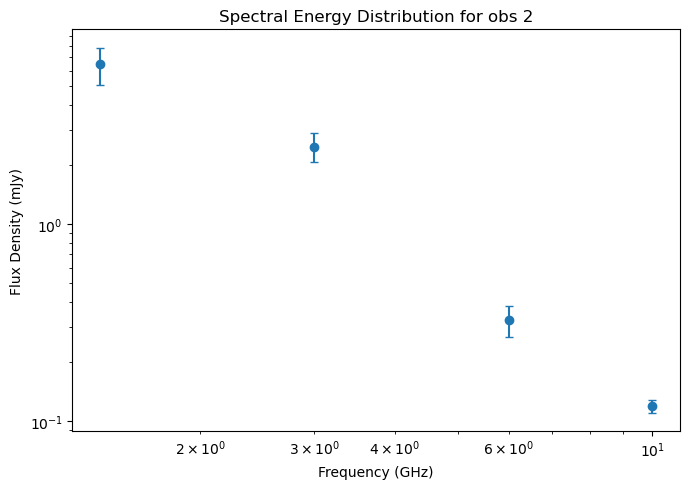

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Frequency in GHz
frequency_GHz = np.array([
    6, 1.4, 10, 3
])

# Flux density in mJy
flux_mJy = np.array([
    0.32594208676500394, 6.440463802068113, 0.11914667739550575, 2.47
])

# Flux density uncertainties in mJy
flux_err_mJy = np.array([
    5.958849079367823e-02, 1.4009574933339286, 9.017798869610036e-03, 0.42
])

plt.figure(figsize=(7, 5))

plt.errorbar(
    frequency_GHz,
    flux_mJy,
    yerr=flux_err_mJy,
    fmt='o',
    capsize=3
)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Flux Density (mJy)")
plt.title("Spectral Energy Distribution for obs 2")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()



In [25]:
import astropy.units as u
from astropy.modeling import fitting
from astropy.modeling.models import custom_model

# Frequency in GHz
nu_GHz = np.array([
    6, 1.4, 10, 3
], dtype=float) * u.GHz

# Flux density in mJy
F_mJy = np.array([
    0.32594208676500394, 6.440463802068113, 0.11914667739550575, 2.47
], dtype=float) * u.mJy


Ferr_mJy = np.array([
    5.958849079367823e-02, 1.4009574933339286, 9.017798869610036e-03, 0.42
], dtype=float) * u.mJy

@custom_model
def DeMarchiBPL(nu,
                Fbrk=1.0,
                nu_brk=5.0,
                alpha1=-1.0,
                alpha2=2.5,
                s=-1.0):

    if nu_brk <= 0 or Fbrk <= 0 or s == 0:
        return np.full_like(nu, np.nan, dtype=float)

    x = nu / nu_brk

    t1 = x**(alpha1 / s)
    t2 = x**(alpha2 / s)
    inside = t1 + t2

    # Guard against non-finite values during fitting
    if np.any(~np.isfinite(inside)) or np.any(inside <= 0):
        return np.full_like(nu, np.nan, dtype=float)

    return Fbrk * inside**s


# Strip units for fitting (keep your plotting/labels in GHz & mJy)
x = nu_GHz.to_value(u.GHz)
y = F_mJy.to_value(u.mJy)
sigma = Ferr_mJy.to_value(u.mJy)

# ---- initial guesses (reasonable defaults) ----
init = DeMarchiBPL(
    Fbrk=np.nanmax(y),
    nu_brk=x[np.nanargmax(y)],
    alpha1=-1.0,
    alpha2=2.5,
    s = -1.0
)

# ---- optionally fix parameters (like DeMarchi "BPL1": s=-1, alpha2=2.5) ----
init.s.fixed = True
init.alpha2.fixed = True

# If you want only s fixed (their "BPL2"), uncomment just this:
# init.s.fixed = True

# If you want only alpha2 fixed (their "BPL3"), uncomment just this:
# init.alpha2.fixed = True

fitter = fitting.LevMarLSQFitter()

best = fitter(init, x, y)

model_vals = best(x)

chi2 = np.sum(((y - model_vals) / sigma)**2)

# Count free (not fixed, not tied) parameters in the fitted model
n_free = 0
for name in best.param_names:
    par = getattr(best, name)
    is_fixed = getattr(par, "fixed", False)
    is_tied = getattr(par, "tied", False) not in (False, None)
    if (not is_fixed) and (not is_tied):
        n_free += 1

dof = len(y) - n_free
chi2_red = chi2 / dof

print(f"Free parameters = {n_free}")
print(f"dof = {dof}")
print(f"chi^2_red = {chi2_red:.3f}")

chi2_red = chi2 / dof

print("Chi^2 =", chi2)
print("Reduced Chi^2 =", chi2_red)

cov = fitter.fit_info.get("param_cov")

param_names = best.param_names
param_vals = np.array([getattr(best, p).value for p in param_names], dtype=float)

param_errs = None
if cov is not None and np.all(np.isfinite(cov)):
    cov_scaled = cov * chi2_red
    errs = np.sqrt(np.diag(cov_scaled))
    # Only free parameters appear in cov; fixed ones are omitted.
    # Build full error array aligned to param_names:
    param_errs = np.full_like(param_vals, np.nan, dtype=float)

    free_mask = np.array([not getattr(getattr(best, p), "fixed", False) for p in param_names])
    param_errs[free_mask] = errs
else:
    print("No covariance matrix returned; parameter errors not available from fit_info.")


Free parameters = 3
dof = 1
chi^2_red = 21.368
Chi^2 = 21.36831072705446
Reduced Chi^2 = 21.36831072705446


In [7]:
# ---------- PRINT PARAM TABLE ----------
print("\nBest-fit parameters (±1σ, where available):")
for i, p in enumerate(param_names):
    v = param_vals[i]
    e = None if param_errs is None else param_errs[i]
    fixed = getattr(getattr(best, p), "fixed", False)

    if fixed:
        print(f"  {p:8s} = {v:.6g}   (fixed)")
    else:
        if e is None or not np.isfinite(e):
            print(f"  {p:8s} = {v:.6g}   (err N/A)")
        else:
            print(f"  {p:8s} = {v:.6g} ± {e:.2g}")

# ---------- PLOT ----------
nu_grid = np.logspace(np.log10(np.min(x)*0.8), np.log10(np.max(x)*1.2), 500)
model_grid = best(nu_grid)

plt.figure(figsize=(7, 5))
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=3, label='Data')
plt.plot(nu_grid, model_grid, label='Eq. (28) best-fit')

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Flux Density (mJy)")

plt.title(rf"Radio SED fit (unweighted), $\chi^2_\nu$={chi2_red:.2f}")
plt.legend()
plt.tight_layout()
plt.show()


Best-fit parameters (±1σ, where available):


NameError: name 'param_names' is not defined

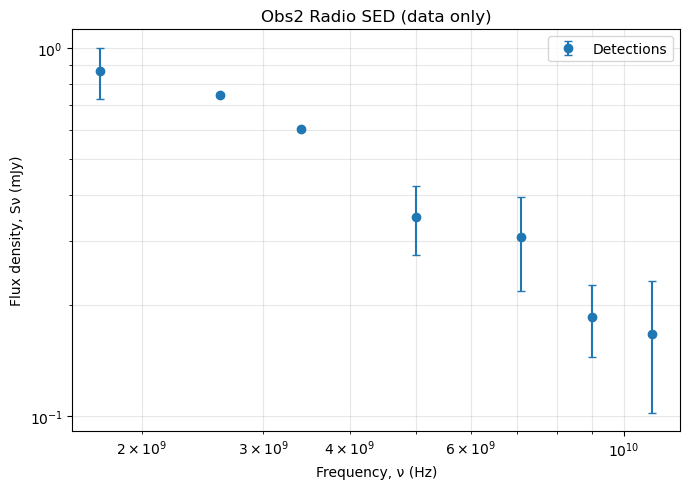


SSA-constrained fit (Flux in mJy):
  F_brk  = 1.54133 ± 0.0678 mJy
  nu_brk = 1.6068 ± 0.243 GHz
  alpha2 = -1.17582 ± 0.159
  chi2 = 1.124
  reduced chi2 = 0.2811


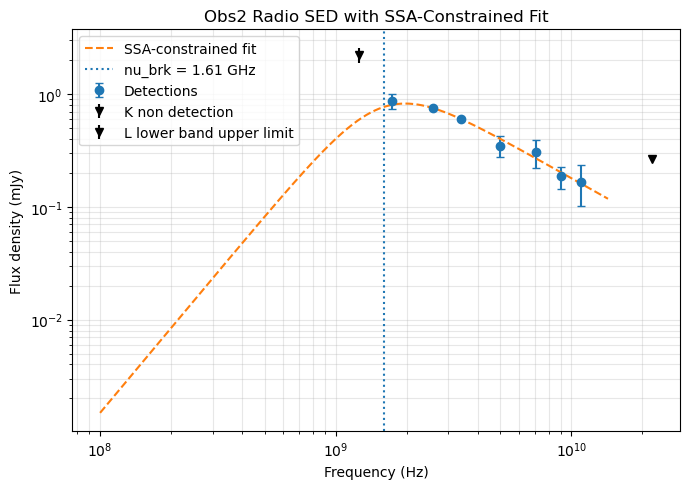

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# SSA-constrained smooth broken power law (De Marchi Eq. 28 style)
# Constraints: s = 1, alpha_1 = 2.5
# Free params: F_brk, nu_brk, alpha_2
# ----------------------------
def eq28_ssa(nu, F_brk, nu_brk, alpha_2):
    alpha_1 = 2.5
    s = -1.0
    x = nu / nu_brk
    return F_brk * (x**(alpha_1/s) + x**(alpha_2/s)) ** (s)

# ----------------------------
# DATA (your updated SPW-level points)
# Frequencies in GHz
# Fluxes in mJy
# ----------------------------
nu_GHz = np.array([4.999, 7.099, 1.739, 8.999, 10.999, 2.599, 3.399])
nu = nu_GHz * 1e9  # Hz

Flux = np.array([0.34828, 0.30676, 0.86709, 0.18573, 0.16745, 0.74694, 0.60158])
Flux_err = np.array([0.07440, 0.08804, 0.13743, 0.04086, 0.06541, 0.00739, 0.00660])

# Sort by frequency for clean plotting
idx = np.argsort(nu)
nu = nu[idx]
Flux = Flux[idx]
Flux_err = Flux_err[idx]
# ----------------------------
# INITIAL PLOT (data only)
# ----------------------------
plt.figure(figsize=(7, 5))
plt.errorbar(nu, Flux, yerr=Flux_err, fmt='o', capsize=3, label='Detections')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency, ν (Hz)')
plt.ylabel('Flux density, Sν (mJy)')
plt.title('Obs2 Radio SED (data only)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# SSA-CONSTRAINED FIT
# Key fix: constrain nu_brk to lie near the peak your data suggest (~1–2 GHz),
# otherwise the optimizer can dump nu_brk << 1 GHz and you see a straight line.
# ----------------------------

# Initial guesses: peak near max(Flux)
F0 = float(np.max(Flux))                # mJy
nu0 = float(nu[np.argmax(Flux)])        # Hz
a20 = -1.0

p0 = [F0, nu0, a20]

# Bounds:
# - F_brk: keep it reasonable for mJy data so it can't "cheat" by going huge
# - nu_brk: keep it inside a sensible range for your dataset
# - alpha2: observationally reasonable
bounds = (
    [0.0, 1e9, -3.0],   # F_brk > 0 mJy, nu_brk > 0.8 GHz, alpha2 >= -3
    [ 5, 5.0e9, 0.0]    # F_brk < 20 mJy, nu_brk < 2.5 GHz, alpha2 <= 0
)

popt, pcov = curve_fit(
    eq28_ssa,
    nu, Flux,
    sigma=Flux_err,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=200000
)

F_brk, nu_brk, alpha2 = popt
perr = np.sqrt(np.diag(pcov))

print("\nSSA-constrained fit (Flux in mJy):")
print(f"  F_brk  = {F_brk:.6g} ± {perr[0]:.3g} mJy")
print(f"  nu_brk = {nu_brk/1e9:.6g} ± {perr[1]/1e9:.3g} GHz")
print(f"  alpha2 = {alpha2:.6g} ± {perr[2]:.3g}")

# Goodness-of-fit
model = eq28_ssa(nu, *popt)
chi2 = np.sum(((Flux - model) / Flux_err) ** 2)
dof = len(Flux) - len(popt)
print(f"  chi2 = {chi2:.4g}")
print(f"  reduced chi2 = {chi2/dof:.4g}")

# ----------------------------
# PLOT DATA + FIT (and mark the break frequency)
# ----------------------------
nu_fit = np.logspace(np.log10(0.1e9), np.log10(nu.max() * 1.3), 800)  # start at 0.1 GHz to show turnover
S_fit = eq28_ssa(nu_fit, *popt)

plt.figure(figsize=(7, 5))
plt.errorbar(nu, Flux, yerr=Flux_err, fmt='o', capsize=3, label='Detections')
plt.plot(nu_fit, S_fit, '--', label='SSA-constrained fit')
plt.axvline(nu_brk, linestyle=':', label=f'nu_brk = {nu_brk/1e9:.2f} GHz')

plt.errorbar(22.064*1e9 ,0.267, yerr=0.0254 * 0.5, fmt='v', color='k', label='K non detection')
plt.errorbar(1.255*1e9 ,2.24038, yerr=0.68264 * 0.5, fmt='v', color='k', label='L lower band upper limit')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Flux density (mJy)')
plt.title('Obs2 Radio SED with SSA-Constrained Fit')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



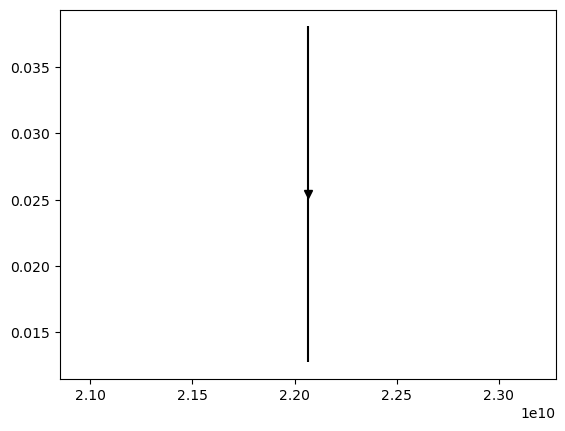

In [4]:
plt.errorbar(22.064*1e9 ,0.0254, yerr=0.0254 * 0.5, fmt='v', color='k', label='3σ upper limit')

plt.show()